In [2]:
import numpy as np
import os
from ase.io import read
import matplotlib.pyplot as plt
from ase.geometry.analysis import Analysis 
from ase.neighborlist import NeighborList

In [3]:
cwd = os.getcwd()

fcc       = read(os.path.join(cwd, 'FCC.vasp'))
bcc       = read(os.path.join(cwd, 'BCC.vasp'))
amorphous = read(os.path.join(cwd, 'amorphous.vasp'))

In [4]:
def compute_rdf_stream(atoms, rmax=10.0, nbins=1000, sample_stride=1, elements_pair=None):
   
    assert np.all(atoms.pbc), "pbc/cell을 설정하세요 (정규화에 필요)."
    N = len(atoms)
    vol = atoms.get_volume()
    if vol <= 0:
        raise ValueError("셀 부피가 0입니다. 유효한 cell이 필요합니다.")

    # 원소쌍 필터(선택)
    symbols = atoms.get_chemical_symbols()
    if elements_pair is not None:
        a_sym, b_sym = elements_pair
        mask_center  = np.array([s == a_sym for s in symbols])
        mask_neighbor= np.array([s == b_sym for s in symbols])
    else:
        mask_center  = np.ones(N, dtype=bool)
        mask_neighbor= np.ones(N, dtype=bool)

    # NeighborList: 페어 컷오프 rmax을 위해 per-atom cutoffs=rmax/2 (pair cutoff는 합으로 계산됨)
    cutoffs = np.full(N, rmax/2.0, dtype=float)
    nl = NeighborList(cutoffs=cutoffs, self_interaction=False, bothways=False, skin=0.0)
    nl.update(atoms)

    # 히스토그램 준비
    hist = np.zeros(nbins, dtype=np.float64)
    dr   = rmax / nbins
    cell = atoms.get_cell().array
    pos  = atoms.get_positions()

    # 기준 원자 샘플링
    centers = np.arange(N)[mask_center][::sample_stride]
    n_centers = len(centers)

    for i in centers:
        idx_j, offsets = nl.get_neighbors(i)   # neighbors of i
        if idx_j.size == 0:
            continue
        # 이웃 중 neighbor 원소 필터
        keep = mask_neighbor[idx_j]
        if not np.any(keep):
            continue
        idx_j = idx_j[keep]
        offs  = offsets[keep]

        # 최소영상 거리 벡터 r_ij = (r_j + T·offs) - r_i
        # offs 는 정수 격자 벡터; T·offs 로 실제 셀 이동량을 얻음
        dvec = pos[idx_j] + offs @ cell - pos[i]
        dist = np.linalg.norm(dvec, axis=1)

        # rmax 이내만 카운트
        m = (dist < rmax) & (dist > 1e-12)
        if not np.any(m):
            continue
        k = (dist[m] / dr).astype(int)
        np.add.at(hist, k, 1.0)

    # 정규화: g(r) = counts / (N_center * ρ * 4π r^2 dr)
    # N_center = 샘플링된 기준 원자 수
    rho = N / vol
    r   = (np.arange(nbins) + 0.5) * dr
    shell = 4.0 * np.pi * (r**2) * dr
    g_r = hist / (max(n_centers,1) * rho * shell + 1e-30)

    return r, g_r

In [5]:
def get_rdf(atoms, bins=1000, rmax=10.0, sample_stride=1, elements_pair=None):
    return compute_rdf_stream(atoms, rmax=rmax, nbins=bins,
                               sample_stride=sample_stride,
                               elements_pair=elements_pair)

# 그대로 호출 가능
fcc_r, fcc_g = get_rdf(fcc, bins=1000, rmax=10.0)
bcc_r, bcc_g = get_rdf(bcc, bins=1000, rmax=10.0)
am_r,  am_g  = get_rdf(amorphous, bins=1000, rmax=10.0)

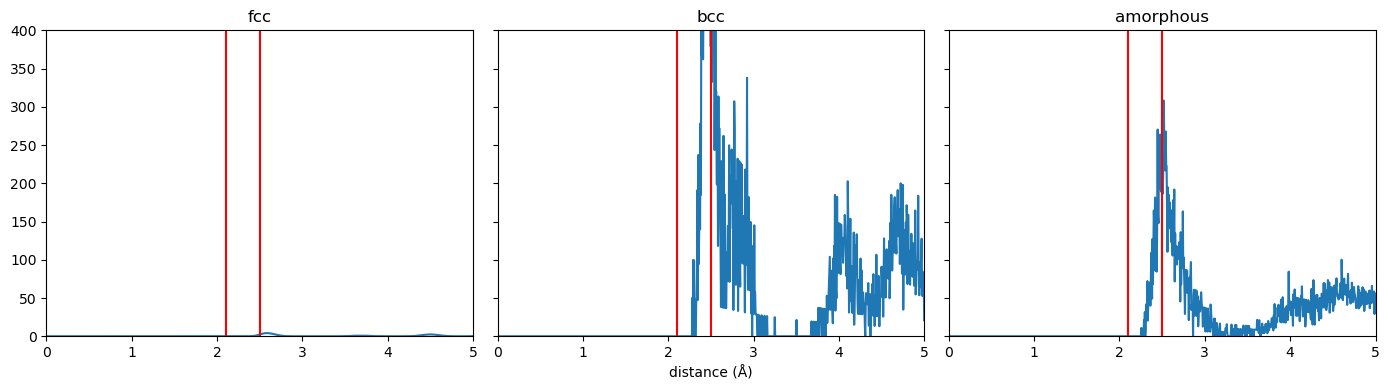

In [6]:
fcc_r, fcc_g = get_rdf(fcc,  bins=1000, rmax=5.0, sample_stride=10)
bcc_r, bcc_g = get_rdf(bcc,  bins=1000, rmax=5.0, sample_stride=10)
am_r, am_g = get_rdf(amorphous, bins=1000, rmax=5.0, sample_stride=10)

# 플로팅
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

ax1.plot(fcc_r, fcc_g); ax1.set_title('fcc');  ax1.set_xlim(0, 5)
ax2.plot(bcc_r, bcc_g); ax2.set_title('bcc');  ax2.set_xlim(0, 5)
ax3.plot(am_r, am_g); ax3.set_title('amorphous'); ax3.set_xlim(0, 5)

ax3.set_ylim(0,400)

ax2.set_xlabel("distance (Å)")
for ax in (ax1, ax2, ax3):
    ax.axvline(2.1, color='red')
    ax.axvline(2.5, color='red')

plt.tight_layout()
plt.show()

In [7]:
import numpy as np
from ase.neighborlist import NeighborList
# (선택) 스무딩
try:
    from scipy.ndimage import gaussian_filter1d
    _HAS_SMOOTH = True
except Exception:
    _HAS_SMOOTH = False

def compute_rdf_stream(atoms, rmax=10.0, nbins=600, sample_stride=1,
                       elements_pair=None, smooth_sigma=None):
    assert np.all(atoms.pbc), "pbc/cell을 설정하세요."
    N   = len(atoms)
    vol = atoms.get_volume()
    if vol <= 0:
        raise ValueError("셀 부피가 0입니다.")

    symbols = atoms.get_chemical_symbols()
    if elements_pair is not None:
        a_sym, b_sym = elements_pair
        mask_center   = np.array([s == a_sym for s in symbols])
        mask_neighbor = np.array([s == b_sym for s in symbols])
    else:
        mask_center   = np.ones(N, dtype=bool)
        mask_neighbor = np.ones(N, dtype=bool)

    # pair cutoff = rmax (각 원자 컷오프 rmax/2로 설정)
    cutoffs = np.full(N, rmax/2.0, dtype=float)
    nl = NeighborList(cutoffs=cutoffs, self_interaction=False, bothways=False, skin=0.0)
    nl.update(atoms)

    hist = np.zeros(nbins, dtype=float)
    dr   = rmax / nbins
    r    = (np.arange(nbins) + 0.5) * dr

    centers = np.arange(N)[mask_center][::sample_stride]
    n_centers = len(centers)
    if n_centers == 0:
        return r, np.zeros_like(r)

    for i in centers:
        idx_j, _ = nl.get_neighbors(i)
        if idx_j.size == 0:
            continue
        keep = mask_neighbor[idx_j]
        if not np.any(keep):
            continue
        idx_j = idx_j[keep]

        # ✅ ASE 제공 최소영상 거리 사용
        dist = atoms.get_distances(i, idx_j, mic=True, vector=False)
        m = (dist < rmax) & (dist > 1e-12)
        if not np.any(m):
            continue
        k = (dist[m] / dr).astype(int)
        k = k[k < nbins]  # 경계 보호
        np.add.at(hist, k, 1.0)

    # 정규화: g(r) = counts / (N_center * ρ * 4π r^2 dr)
    rho = N / vol
    shell = 4.0 * np.pi * r**2 * dr
    g_r = hist / (n_centers * rho * shell + 1e-30)

    # (선택) 스무딩
    if smooth_sigma and _HAS_SMOOTH:
        g_r = gaussian_filter1d(g_r, sigma=smooth_sigma, mode='nearest')

    return r, g_r


In [10]:
# ======== 1. 한 번만 RDF 계산 ========
fcc_r, fcc_g = compute_rdf_stream(fcc, rmax=6.0, nbins=400, sample_stride=5, smooth_sigma=1.0)
bcc_r, bcc_g = compute_rdf_stream(bcc, rmax=6.0, nbins=400, sample_stride=5, smooth_sigma=1.0)
am_r,  am_g  = compute_rdf_stream(amorphous, rmax=6.0, nbins=400, sample_stride=5, smooth_sigma=1.0)

# ======== 2. 플로팅 전용 함수 ========
def plot_rdfs(fcc_data, bcc_data, am_data, red_lines):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14,4), sharey=False)

    # fcc
    ax1.plot(*fcc_data)
    ax1.set_title('fcc')
    ax1.set_xlim(0,6)
    ax1.set_ylim(0, None)
    for x in red_lines[0]:
        ax1.axvline(x, color='red')

    # bcc
    ax2.plot(*bcc_data)
    ax2.set_title('bcc')
    ax2.set_xlim(0,6)
    for x in red_lines[1]:
        ax2.axvline(x, color='red')

    # amorphous
    ax3.plot(*am_data)
    ax3.set_title('amorphous')
    ax3.set_xlim(0,6)
    ax3.set_ylim(0, None)
    for x in red_lines[2]:
        ax3.axvline(x, color='red')

    for ax in (ax1, ax2, ax3):
        ax.set_xlabel("distance (Å)")
        ax.set_ylabel("g(r)")

    plt.tight_layout()
    plt.show()

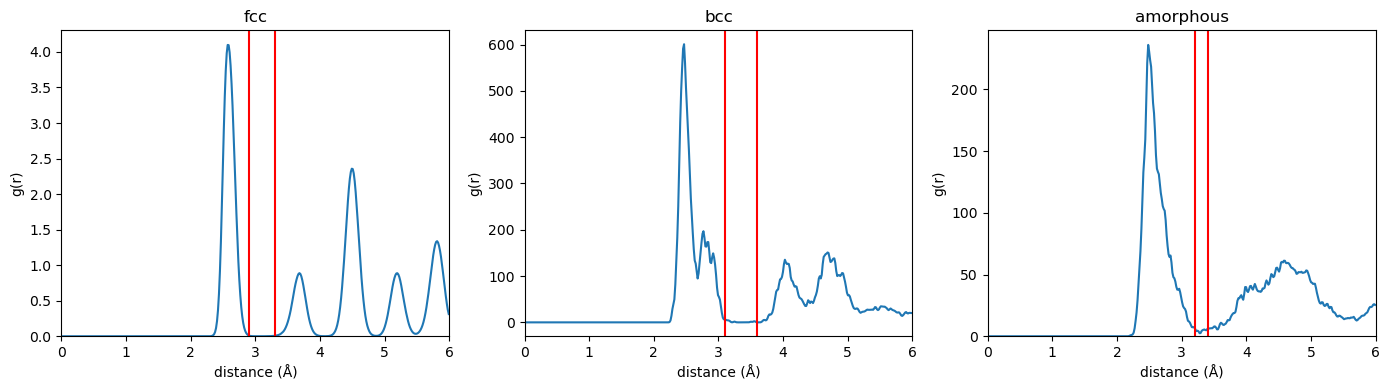

In [16]:
# ======== 3. 필요할 때 빨간선 좌표만 바꿔서 호출 ========
red_lines1 = [[2.9, 3.3], [3.1, 3.6], [3.2, 3.4]]
plot_rdfs((fcc_r, fcc_g), (bcc_r, bcc_g), (am_r, am_g), red_lines1)

# Q6

In [20]:
bcc_q = np.genfromtxt("/home/kjm/metad/qvalue/test_500/bcc/COLVAR")
fcc_q = np.genfromtxt("/home/kjm/metad/qvalue/test_500/fcc/COLVAR")
am_q = np.genfromtxt("/home/kjm/metad/qvalue/test_500/amorphous/COLVAR")

[bcc]
  Mean     : 0.5128
  Median   : 0.5128
  Std Dev  : 0.0003
  Min      : 0.5117
  Max      : 0.5194

[fcc]
  Mean     : 0.5677
  Median   : 0.5677
  Std Dev  : 0.0019
  Min      : 0.5654
  Max      : 0.5844

[amorphous]
  Mean     : 0.0552
  Median   : 0.0557
  Std Dev  : 0.0034
  Min      : 0.0418
  Max      : 0.0650



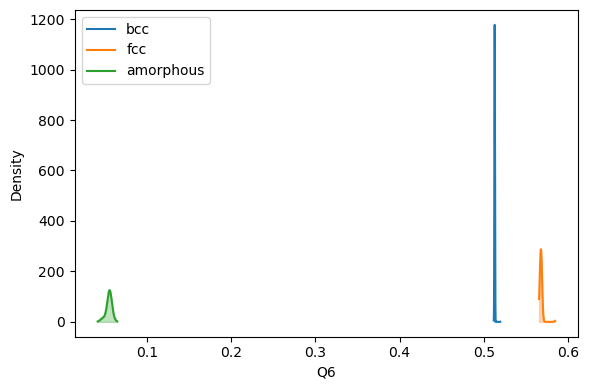

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_kde(ax, data, color, label, bw=0.5, fill=True, alpha=0.3):
    kde = gaussian_kde(data, bw_method=bw)
    x = np.linspace(data.min(), data.max(), 500)
    y = kde(x)
    ax.plot(x, y, color=color, label=label)
    if fill:
        ax.fill_between(x, y, color=color, alpha=alpha)

def print_stats(name, data):
    print(f"[{name}]")
    print(f"  Mean     : {np.mean(data):.4f}")
    print(f"  Median   : {np.median(data):.4f}")
    print(f"  Std Dev  : {np.std(data):.4f}")
    print(f"  Min      : {np.min(data):.4f}")
    print(f"  Max      : {np.max(data):.4f}")
    print()

# COLVAR: time, q6 (두 열) 가정
bcc = np.loadtxt("/home/kjm/metad/qvalue/test_500/bcc/COLVAR", comments="#")
fcc = np.loadtxt("/home/kjm/metad/qvalue/test_500/fcc/COLVAR", comments="#")
am  = np.loadtxt("/home/kjm/metad/qvalue/test_500/amorphous/COLVAR", comments="#")

q6_bcc, q6_fcc, q6_am = bcc[:,1], fcc[:,1], am[:,1]

# 값 확인
print_stats("bcc", q6_bcc)
print_stats("fcc", q6_fcc)
print_stats("amorphous", q6_am)

# KDE 플롯
fig, ax = plt.subplots(figsize=(6,4))
plot_kde(ax, q6_bcc, "C0", "bcc")
plot_kde(ax, q6_fcc, "C1", "fcc")
plot_kde(ax, q6_am,  "C2", "amorphous")
ax.legend()
ax.set_xlabel("Q6")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import gaussian_kde

fig = plt.figure(figsize=(6, 6))
grid = fig.add_gridspec(4, 4, hspace=0, wspace=0)
main_ax = fig.add_subplot(grid[1:4, 0:3])  # 중앙의 scatter plot
x_kde = fig.add_subplot(grid[0, 0:3], sharex=main_ax)  # 위쪽 KDE
y_kde = fig.add_subplot(grid[1:4, 3], sharey=main_ax)  # 오른쪽 KDE

# scatter plot
main_ax.scatter(bcc[:, 1], bcc[:, 2], s=60, label='bcc', color='C0', alpha=0.3)
main_ax.scatter(fcc[:, 1], fcc[:, 2], s=60, label='fcc', color='C1', alpha=0.3)
main_ax.scatter(am[:, 1], am[:, 2], s=60, label='am', color='C2', alpha=0.3)

main_ax.set_xlabel("Q(4)")
main_ax.set_ylabel("Q(6)")
main_ax.legend(loc='upper left')

# 위쪽 KDE
sns.kdeplot(rutile[:, 1], ax=x_kde, color='C0', bw_adjust=0.5, fill=True, alpha=0.3)
sns.kdeplot(anatase[:, 1], ax=x_kde, color='C1', bw_adjust=0.5, fill=True, alpha=0.3)
sns.kdeplot(liquid[:, 1], ax=x_kde, color='C2', bw_adjust=0.5, fill=True, alpha=0.3)
x_kde.axis('off')  # 눈금 제거

# 오른쪽 KDE
sns.kdeplot(y=rutile[:, 2], ax=y_kde, color='C0', bw_adjust=0.5, fill=True, alpha=0.3)
sns.kdeplot(y=anatase[:, 2], ax=y_kde, color='C1', bw_adjust=0.5, fill=True, alpha=0.3)
sns.kdeplot(y=liquid[:, 2], ax=y_kde, color='C2', bw_adjust=0.5, fill=True, alpha=0.3)
y_kde.axis('off')  # 눈금 제거

# 각 subplot의 여백 제거
x_kde.margins(x=0)  # 위쪽 KDE 플롯의 여백 제거
y_kde.margins(y=0)  # 오른쪽 KDE 플롯의 여백 제거

# Compute modes for the x-variable (Q(4))
datasets_x = {
    'rutile': {'data': rutile[:, 1], 'color': 'C0'},
    'anatase': {'data': anatase[:, 1], 'color': 'C1'},
    'liquid': {'data': liquid[:, 1], 'color': 'C2'},
    'brookite': {'data': brookite[:, 1], 'color': 'C3'}
}

modes_x = {}
for name, info in datasets_x.items():
    data = info['data']
    kde = gaussian_kde(data, bw_method=0.5)
    x_vals = np.linspace(data.min(), data.max(), 1000)
    density = kde(x_vals)
    x_mode = x_vals[np.argmax(density)]
    modes_x[name] = {'mode': x_mode, 'color': info['color']}
    # Draw vertical lines on x_kde and main_ax
    x_kde.axvline(x_mode, color=info['color'], linestyle='--')
    main_ax.axvline(x_mode, color=info['color'], linestyle='--', alpha=0.7)
    # Print the mode value
    print(f"Mode of {name} for Q(4): {x_mode:.4f}")

# Compute modes for the y-variable (Q(6))
datasets_y = {
    'rutile': {'data': rutile[:, 2], 'color': 'C0'},
    'anatase': {'data': anatase[:, 2], 'color': 'C1'},
    'liquid': {'data': liquid[:, 2], 'color': 'C2'},
    'brookite': {'data': brookite[:, 2], 'color': 'C3'}
}

modes_y = {}
for name, info in datasets_y.items():
    data = info['data']
    kde = gaussian_kde(data, bw_method=0.5)
    y_vals = np.linspace(data.min(), data.max(), 1000)
    density = kde(y_vals)
    y_mode = y_vals[np.argmax(density)]
    modes_y[name] = {'mode': y_mode, 'color': info['color']}
    # Draw horizontal lines on y_kde and main_ax
    y_kde.axhline(y_mode, color=info['color'], linestyle='--')
    main_ax.axhline(y_mode, color=info['color'], linestyle='--', alpha=0.7)
    # Print the mode value
    print(f"Mode of {name} for Q(6): {y_mode:.4f}")

# Save figure
#plt.savefig('Order_params.png', dpi=500, bbox_inches='tight', transparent=True)

Mode of bcc for Q(4): 0.5128
Mode of fcc for Q(4): 0.5676
Mode of am for Q(4): 0.0559
Mode of bcc for Q(6): 0.0311
Mode of fcc for Q(6): 0.1591
Mode of am for Q(6): 0.0062


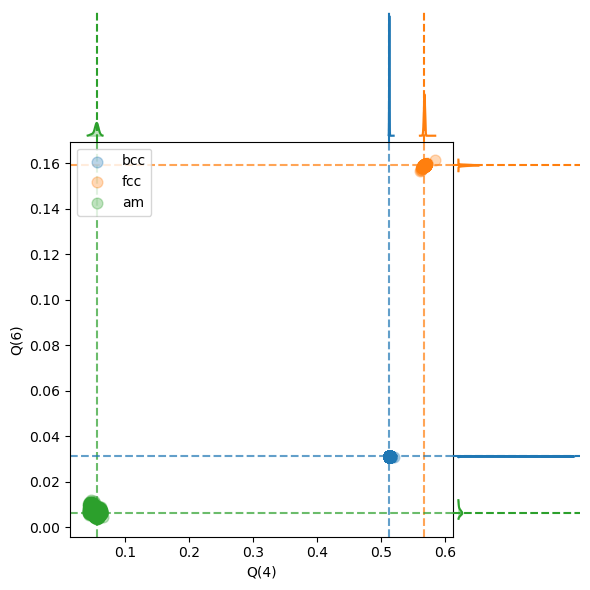

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 데이터 로드
bcc_q = np.genfromtxt("/home/kjm/metad/qvalue/test_500/bcc/test/COLVAR")
fcc_q = np.genfromtxt("/home/kjm/metad/qvalue/test_500/fcc/test/COLVAR")
am_q  = np.genfromtxt("/home/kjm/metad/qvalue/test_500/amorphous/test/COLVAR")

def plot_kde(ax, data, color, bw=0.5, fill=True, alpha=0.3, orientation='vertical'):
    kde = gaussian_kde(data, bw_method=bw)
    grid = np.linspace(data.min(), data.max(), 500)
    density = kde(grid)

    if orientation == 'vertical':
        ax.plot(grid, density, color=color)
        if fill:
            ax.fill_between(grid, density, color=color, alpha=alpha)
    elif orientation == 'horizontal':
        ax.plot(density, grid, color=color)
        if fill:
            ax.fill_betweenx(grid, density, color=color, alpha=alpha)

# 플롯 레이아웃
fig = plt.figure(figsize=(6, 6))
grid_spec = fig.add_gridspec(4, 4, hspace=0, wspace=0)
main_ax = fig.add_subplot(grid_spec[1:4, 0:3])
x_kde   = fig.add_subplot(grid_spec[0, 0:3], sharex=main_ax)
y_kde   = fig.add_subplot(grid_spec[1:4, 3], sharey=main_ax)

# Scatter (Q4 vs Q6) — 여기서는 COLVAR에 Q4, Q6가 둘 다 있다고 가정
main_ax.scatter(bcc_q[:, 1], bcc_q[:, 2], s=60, label='bcc', color='C0', alpha=0.3)
main_ax.scatter(fcc_q[:, 1], fcc_q[:, 2], s=60, label='fcc', color='C1', alpha=0.3)
main_ax.scatter(am_q[:, 1],  am_q[:, 2],  s=60, label='am',  color='C2', alpha=0.3)
main_ax.set_xlabel("Q(4)")
main_ax.set_ylabel("Q(6)")
main_ax.legend(loc='upper left')

# 위쪽 KDE (Q4)
plot_kde(x_kde, bcc_q[:, 1], color='C0', bw=0.5)
plot_kde(x_kde, fcc_q[:, 1], color='C1', bw=0.5)
plot_kde(x_kde, am_q[:, 1],  color='C2', bw=0.5)
x_kde.axis('off')

# 오른쪽 KDE (Q6)
plot_kde(y_kde, bcc_q[:, 2], color='C0', bw=0.5, orientation='horizontal')
plot_kde(y_kde, fcc_q[:, 2], color='C1', bw=0.5, orientation='horizontal')
plot_kde(y_kde, am_q[:, 2],  color='C2', bw=0.5, orientation='horizontal')
y_kde.axis('off')

# 모드 계산 (Q4)
datasets_x = {
    'bcc': {'data': bcc_q[:, 1], 'color': 'C0'},
    'fcc': {'data': fcc_q[:, 1], 'color': 'C1'},
    'am':  {'data': am_q[:, 1],  'color': 'C2'}
}
for name, info in datasets_x.items():
    data = info['data']
    kde = gaussian_kde(data, bw_method=0.5)
    x_vals = np.linspace(data.min(), data.max(), 1000)
    density = kde(x_vals)
    x_mode = x_vals[np.argmax(density)]
    x_kde.axvline(x_mode, color=info['color'], linestyle='--')
    main_ax.axvline(x_mode, color=info['color'], linestyle='--', alpha=0.7)
    print(f"Mode of {name} for Q(4): {x_mode:.4f}")

# 모드 계산 (Q6)
datasets_y = {
    'bcc': {'data': bcc_q[:, 2], 'color': 'C0'},
    'fcc': {'data': fcc_q[:, 2], 'color': 'C1'},
    'am':  {'data': am_q[:, 2],  'color': 'C2'}
}
for name, info in datasets_y.items():
    data = info['data']
    kde = gaussian_kde(data, bw_method=0.5)
    y_vals = np.linspace(data.min(), data.max(), 1000)
    density = kde(y_vals)
    y_mode = y_vals[np.argmax(density)]
    y_kde.axhline(y_mode, color=info['color'], linestyle='--')
    main_ax.axhline(y_mode, color=info['color'], linestyle='--', alpha=0.7)
    print(f"Mode of {name} for Q(6): {y_mode:.4f}")

plt.tight_layout()
plt.show()
